# Chapter 22. 프로젝트 II:PyTorch Connector를 활용한 양자-고전 하이브리드 프로젝트

## 개요

이 노트북은 Qiskit Machine Learning의 **TorchConnector**를 사용하여 양자 신경망(QNN)과 PyTorch 모델을 통합하는 두 가지 실무 프로젝트를 다룬다.

### 프로젝트 목표

1. **Part 1: 정형 데이터 분류** - 2D 이진 분류 문제에서 EstimatorQNN과 SamplerQNN의 차이를 비교한다.
2. **Part 2: 이미지 분류** - 전통적 CNN을 양자 처리 계층과 결합하여 MNIST의 0과 1을 분류한다.

### 핵심 개념

- **TorchConnector**: Qiskit QNN을 PyTorch 모듈로 래핑
- **EstimatorQNN**: 기댓값 계산 기반 QNN
- **SamplerQNN**: 샘플링 기반 확률적 QNN
- **하이브리드 학습**: PyTorch 옵티마이저를 통한 양자-고전 동시 학습


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import Tensor, cat, no_grad, manual_seed
from torch.nn import Linear, CrossEntropyLoss, MSELoss, Module, Conv2d, Dropout2d, NLLLoss, MaxPool2d, Flatten, Sequential, ReLU
from torch.optim import LBFGS, Adam
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.optim as optim
import torch.nn.functional as F
import os

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import real_amplitudes, zz_feature_map
from qiskit.primitives import StatevectorEstimator as Estimator, StatevectorSampler as Sampler
from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

## Part 1. 정형 데이터 분류: EstimatorQNN + PyTorch

### 문제 설정

2D 평면의 점들을 이진 분류하는 문제를 다룬다. 양자 회로를 사용하여 고차원 특성 공간을 학습한다.

- **입력**: 2D 벡터 (x, y)
- **출력**: 클래스 레이블 (0 또는 1)
- **양자 큐비트**: 2
- **옵티마이저**: L-BFGS (Quasi-Newton method)


### 4.1 데이터셋 생성

랜덤하게 생성한 2D 이진 분류 데이터셋을 준비한다. 데이터는 두 입력의 합이 0 이상이면 클래스 1, 미만이면 클래스 0으로 분류된다.


In [2]:
# 난수 생성 시드 고정
algorithm_globals.random_seed = 42

# 데이터셋 파라미터
num_inputs = 2
num_samples = 20

# 2D 포인트 생성 ([-1, 1] 범위)
X = 2 * algorithm_globals.random.random([num_samples, num_inputs]) - 1

# y = 1 if sum(x, y) >= 0 else 0
y01 = 1 * (np.sum(X, axis=1) >= 0)

# -1/+1 레이블로 변환
y = 2 * y01 - 1

# PyTorch 텐서 변환
X_ = Tensor(X)
y01_ = Tensor(y01).reshape(len(y)).long()
y_ = Tensor(y).reshape(len(y), 1)

print(f"데이터 형태: X={X_.shape}, y={y_.shape}")
print(f"클래스 분포: {np.bincount(y01)}")

데이터 형태: X=torch.Size([20, 2]), y=torch.Size([20, 1])
클래스 분포: [10 10]


/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47448 (\N{HANGUL SYLLABLE RYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from f

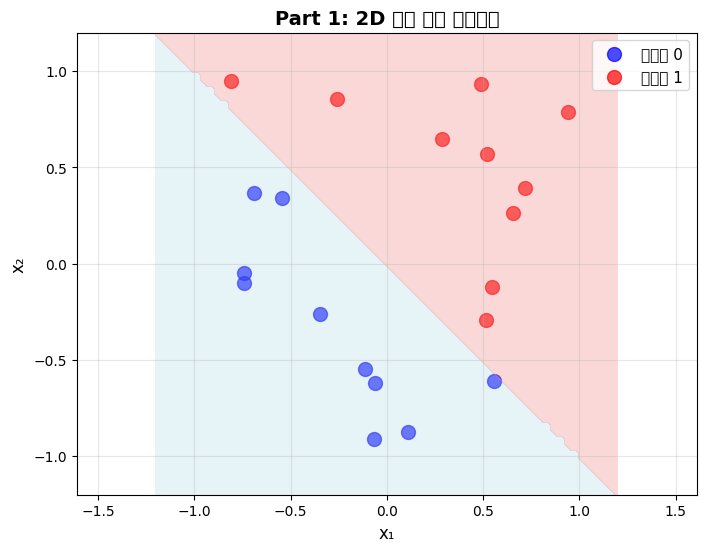

In [3]:
# 데이터 시각화
plt.figure(figsize=(8, 6))
colors = ['blue', 'red']
for c in [0, 1]:
    idx = (y01 == c)
    plt.scatter(X[idx, 0], X[idx, 1], c=colors[c], label=f'클래스 {c}', alpha=0.7, s=100)

# 결정 경계 표시
xx, yy = np.meshgrid(np.linspace(-1.2, 1.2, 100), np.linspace(-1.2, 1.2, 100))
boundary = np.sum(np.stack([xx, yy], axis=2), axis=2) >= 0
plt.contourf(xx, yy, boundary, levels=[0, 0.5, 1], colors=['lightblue', 'lightcoral'], alpha=0.3)

plt.xlabel('x₁', fontsize=12)
plt.ylabel('x₂', fontsize=12)
plt.title('Part 1: 2D 이진 분류 데이터셋', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

### 4.2 양자 회로 설계

**Feature map** (특성 맵)과 **ansatz** (변분 형태)를 결합한 양자 회로를 구성한다.

- **Feature map**: ZZ Feature Map - 입력 데이터를 양자 상태로 인코딩
- **Ansatz**: Real Amplitudes - 학습 가능한 파라미터를 포함한 변분 회로

### ZZ Feature Map이란?

ZZ 특성 맵은 입력 데이터를 양자 상태로 인코딩하는 방법이다. 각 입력은 파울리 Z 게이트와 제어 Z 상호작용(CZ)을 통해 큐비트 상태를 결정한다. 이는 고차원 특성 공간에서 데이터의 구조를 보존하는 효과적인 인코딩 방식이다.


In [4]:
# Feature map 생성 (입력 특성 인코딩)
feature_map = zz_feature_map(num_inputs)
print(f"Feature map 파라미터: {len(feature_map.parameters)}개")

# Ansatz 생성 (학습 가능한 파라미터)
ansatz = real_amplitudes(num_inputs, entanglement="linear", reps=1)
print(f"Ansatz 파라미터: {len(ansatz.parameters)}개")

# 완전한 양자 회로 구성
qc = QuantumCircuit(num_inputs)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)

print(f"\n전체 회로 큐비트 수: {qc.num_qubits}")
print(f"전체 파라미터 수: {len(qc.parameters)}")

Feature map 파라미터: 2개
Ansatz 파라미터: 4개

전체 회로 큐비트 수: 2
전체 파라미터 수: 6


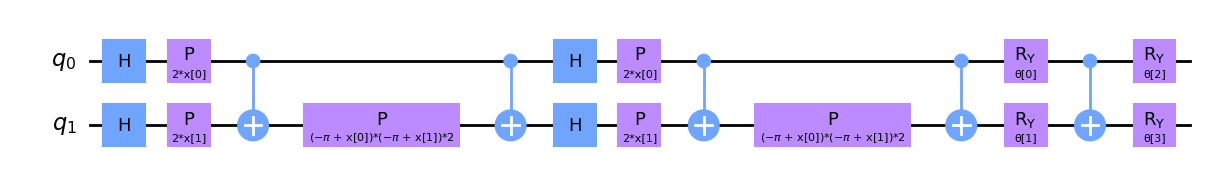

In [5]:
# 양자 회로 시각화
qc.draw(output="mpl", style="clifford")

### 4.3 EstimatorQNN 기반 모델

**EstimatorQNN**은 양자 회로의 기댓값을 연속적으로 계산하여 회귀 또는 분류 작업에 사용한다.

#### EstimatorQNN의 동작 원리

1. **입력 데이터**: 특성 맵 파라미터로 주입
2. **가중치 파라미터**: Ansatz의 학습 가능한 파라미터
3. **기댓값 계산**: 관찰 가능 연산자(Observable)의 기댓값을 계산
4. **출력**: 연속 값 (실수)

#### 핵심 설정

- `input_gradients=True`: PyTorch 역전파와의 호환성을 위해 필수
- `estimator=Estimator()`: 상태벡터 기반 기댓값 계산
- `MSELoss`: 회귀 손실함수 (Mean Squared Error)
- `LBFGS`: 2차 최적화 알고리즘 (Quasi-Newton method)


In [6]:
# Estimator 생성 (상태벡터 기반 계산)
estimator = Estimator()

# EstimatorQNN 생성
qnn = EstimatorQNN(
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    estimator=estimator,
    input_gradients=True,  # 역전파 활성화
)

# TorchConnector로 래핑
initial_weights = algorithm_globals.random.random(qnn.num_weights)
model = TorchConnector(qnn, initial_weights=initial_weights)

print(f"✓ EstimatorQNN 생성 완료")
print(f"  입력 크기: {qnn.num_inputs}")
print(f"  가중치 개수: {qnn.num_weights}")

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


✓ EstimatorQNN 생성 완료
  입력 크기: 2
  가중치 개수: 4


In [7]:
# 최적화 설정
optimizer = LBFGS(model.parameters())
f_loss = MSELoss(reduction="sum")

# 학습 파라미터
epochs = 50
loss_history = []

# 학습
model.train()

def closure():
    """L-BFGS 최적화 함수"""
    optimizer.zero_grad()
    output = model(X_)
    loss = f_loss(output, y_)
    loss.backward()
    return loss

for epoch in range(epochs):
    loss = optimizer.step(closure)
    loss_history.append(loss.item())
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

print("\n✓ EstimatorQNN 학습 완료")

Epoch 10/50, Loss: 14.940438
Epoch 20/50, Loss: 19.924566
Epoch 30/50, Loss: 14.915819
Epoch 40/50, Loss: 14.922295
Epoch 50/50, Loss: 15.031800

✓ EstimatorQNN 학습 완료


#### L-BFGS 최적화 (Limited-memory BFGS)

L-BFGS는 역 헤시안 행렬을 메모리 효율적으로 근사하는 2차 최적화 알고리즘이다.

- **장점**: 1차 그래디언트만 필요, 수렴이 빠름, 하이퍼파라미터 적음
- **특징**: Closure 함수를 통해 각 스텝에서 손실과 그래디언트 재계산
- **사용처**: 소규모 데이터셋, 양자 기계학습

이 구현에서 closure 함수는:
1. 그래디언트 초기화
2. 모델 순전파
3. 손실 계산
4. 역전파를 통한 그래디언트 계산
5. 손실값 반환

을 반복한다.


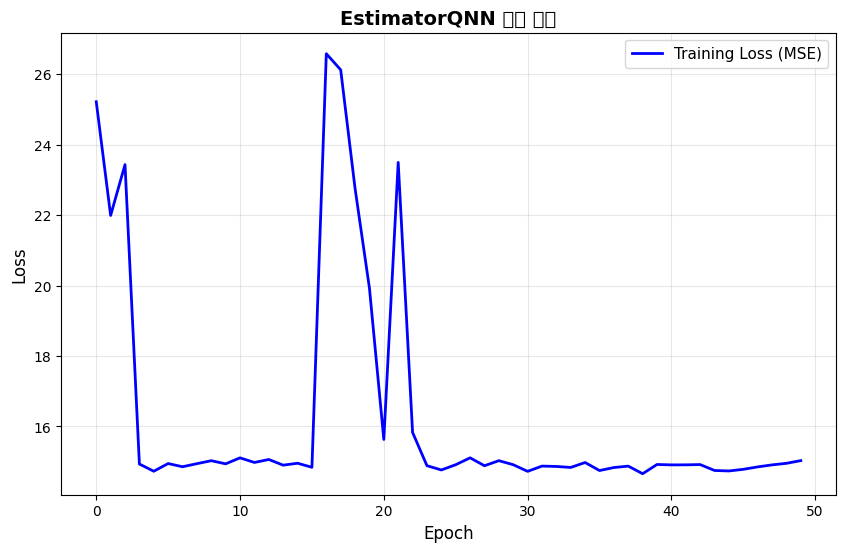

In [10]:
# 학습 곡선 시각화
plt.figure(figsize=(10, 6))
plt.plot(loss_history, 'b-', linewidth=2, label='Training Loss (MSE)')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('EstimatorQNN 학습 곡선', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

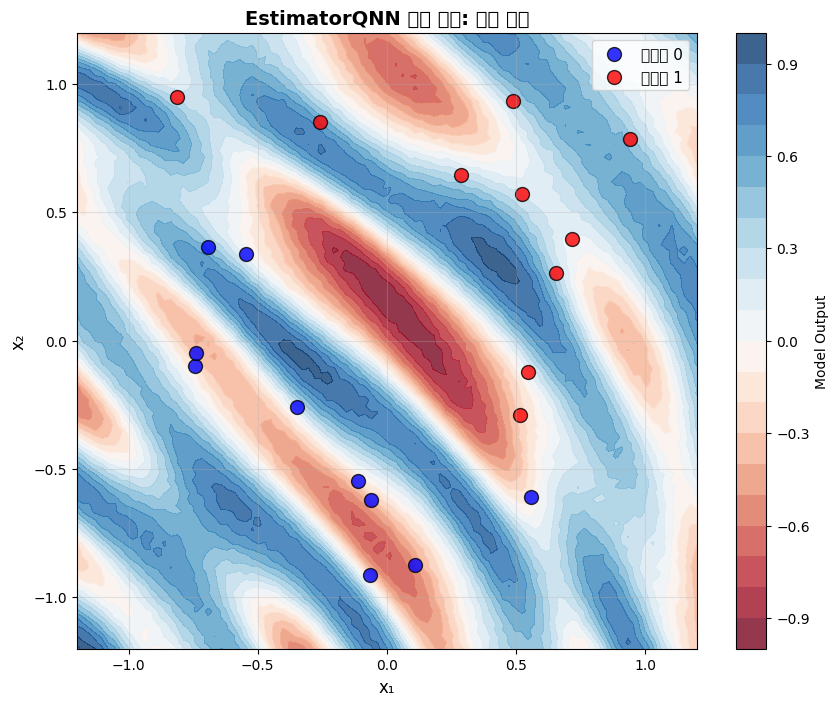

In [11]:
# 결정 경계 시각화
xx, yy = np.meshgrid(np.linspace(-1.2, 1.2, 100), np.linspace(-1.2, 1.2, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]

with no_grad():
    grid_tensor = Tensor(grid_points)
    predictions = model(grid_tensor).detach().numpy()

Z = predictions.reshape(xx.shape)

plt.figure(figsize=(10, 8))
contourf = plt.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.8)
plt.colorbar(contourf, label='Model Output')

# 원래 데이터점 표시
colors = ['blue', 'red']
for c in [0, 1]:
    idx = (y01 == c)
    plt.scatter(
        X[idx, 0], X[idx, 1], 
        c=colors[c], edgecolor='black', 
        s=100, alpha=0.8, 
        label=f'클래스 {c}'
    )

plt.xlabel('x₁', fontsize=12)
plt.ylabel('x₂', fontsize=12)
plt.title('EstimatorQNN 학습 결과: 결정 경계', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

### 4.4 SamplerQNN 기반 모델

**SamplerQNN**은 양자 회로의 샘플링 결과를 해석하여 분류 작업에 사용한다.

#### SamplerQNN의 동작 원리

1. **입력 데이터**: 특성 맵 파라미터로 주입
2. **가중치 파라미터**: Ansatz의 학습 가능한 파라미터
3. **샘플링**: 양자 회로를 측정하여 비트 문자열 생성
4. **해석 함수**: 비트 문자열을 클래스 확률로 변환 (e.g., 패리티 함수)
5. **출력**: 클래스 확률 벡터

#### 핵심 설정

- `interpret`: 측정 결과를 클래스 레이블로 변환하는 함수
- `output_shape`: 출력 클래스 수 (이 경우 2)
- `sampler=Sampler()`: 상태벡터 기반 샘플링
- `CrossEntropyLoss`: 분류 손실함수

#### 패리티 함수 (Parity Function)

패리티 함수는 측정된 비트 문자열에서 1의 개수를 세어 홀수면 1, 짝수면 0으로 변환한다. 이는 간단하지만 효과적인 양자 출력 해석 방법이다.


In [12]:
# Sampler 생성 (상태벡터 샘플링)
sampler = Sampler()

# 패리티 해석 함수 (측정 결과 해석)
parity = lambda x: "{:b}".format(x).count("1") % 2

# 새로운 양자 회로 생성
qc_sampler = QuantumCircuit(num_inputs)
qc_sampler.compose(feature_map, inplace=True)
qc_sampler.compose(ansatz, inplace=True)

# SamplerQNN 생성
qnn_sampler = SamplerQNN(
    circuit=qc_sampler,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    interpret=parity,
    output_shape=2,  # 이진 분류
    sampler=sampler,
    input_gradients=True,  # 역전파 활성화
)

# TorchConnector로 래핑
initial_weights_sampler = algorithm_globals.random.random(qnn_sampler.num_weights)
model_sampler = TorchConnector(
    qnn_sampler, 
    initial_weights=initial_weights_sampler
)

print(f"✓ SamplerQNN 생성 완료")
print(f"  입력 크기: {qnn_sampler.num_inputs}")
print(f"  출력 크기: {qnn_sampler.output_shape}")
print(f"  가중치 개수: {qnn_sampler.num_weights}")


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


✓ SamplerQNN 생성 완료
  입력 크기: 2
  출력 크기: (2,)
  가중치 개수: 4


In [13]:
# 최적화 설정
optimizer_sampler = LBFGS(model_sampler.parameters())
f_loss_sampler = CrossEntropyLoss()

# 학습 파라미터
epochs_sampler = 50
loss_history_sampler = []

# 학습
model_sampler.train()

def closure_sampler():
    """L-BFGS 최적화 함수"""
    optimizer_sampler.zero_grad()
    output = model_sampler(X_)
    loss = f_loss_sampler(output, y01_)
    loss.backward()
    return loss

for epoch in range(epochs_sampler):
    loss = optimizer_sampler.step(closure_sampler)
    loss_history_sampler.append(loss.item())
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs_sampler}, Loss: {loss.item():.6f}")

print("\n✓ SamplerQNN 학습 완료")

Epoch 10/50, Loss: 0.680738
Epoch 20/50, Loss: 0.615591
Epoch 30/50, Loss: 0.614692
Epoch 40/50, Loss: 0.614469
Epoch 50/50, Loss: 0.616082

✓ SamplerQNN 학습 완료


/var/folders/v9/46y9d8bn1lxgjt7g439hsf8c0000gn/T/ipykernel_53761/2121147110.py:16: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/v9/46y9d8bn1lxgjt7g439hsf8c0000gn/T/ipykernel_53761/2121147110.py:16: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/v9/46y9d8bn1lxgjt7g439hsf8c0000gn/T/ipykernel_53761/2121147110.py:16: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/v9/46y9d8bn1lxgjt7g439hsf8c0000gn/T/ipykernel_53761/2121147110.py:16: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/

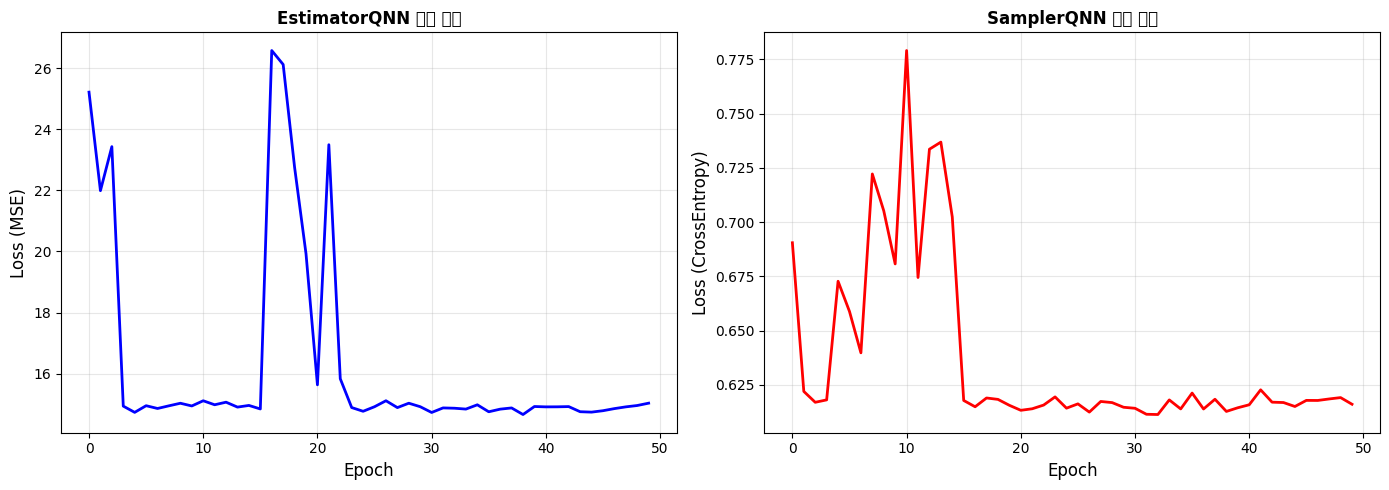

In [14]:
# 학습 곡선 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(loss_history, 'b-', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('EstimatorQNN 학습 곡선', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(loss_history_sampler, 'r-', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss (CrossEntropy)', fontsize=12)
axes[1].set_title('SamplerQNN 학습 곡선', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) miss

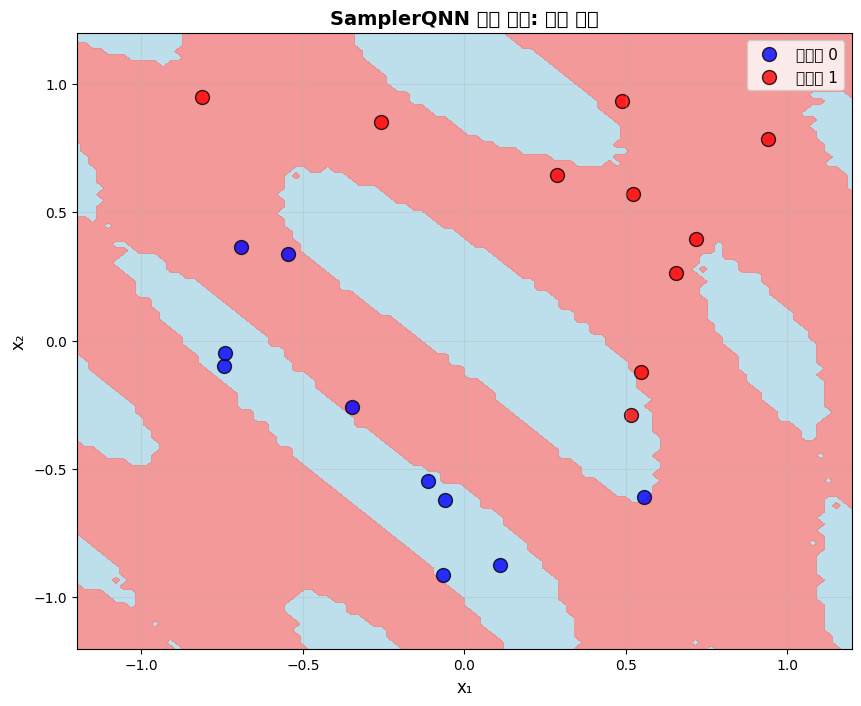

In [15]:
# SamplerQNN 결정 경계 시각화
with no_grad():
    grid_tensor = Tensor(grid_points)
    predictions_sampler = model_sampler(grid_tensor).detach().numpy()

# 클래스 레이블로 변환 (argmax)
Z_sampler = np.argmax(predictions_sampler, axis=1).reshape(xx.shape)

plt.figure(figsize=(10, 8))
contourf = plt.contourf(
    xx, yy, Z_sampler, 
    levels=[0, 0.5, 1], 
    colors=['lightblue', 'lightcoral'], 
    alpha=0.8
)

# 원래 데이터점 표시
colors = ['blue', 'red']
for c in [0, 1]:
    idx = (y01 == c)
    plt.scatter(
        X[idx, 0], X[idx, 1], 
        c=colors[c], edgecolor='black', 
        s=100, alpha=0.8, 
        label=f'클래스 {c}'
    )

plt.xlabel('x₁', fontsize=12)
plt.ylabel('x₂', fontsize=12)
plt.title('SamplerQNN 학습 결과: 결정 경계', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

## Part 2. MNIST 이미지 분류: 하이브리드 CNN-QNN

### 문제 설정

전통적인 CNN을 양자 처리 계층과 결합하여 MNIST 데이터셋의 숫자 0과 1을 분류한다.

#### 아키텍처 개요

```
MNIST 이미지 (28x28)
    ↓
CNN 레이어들 (특성 추출)
    ↓
완전 연결층 (2D 축소)
    ↓
QNN (양자 처리)
    ↓
완전 연결층 (분류)
```

#### 세부 파라미터

- **데이터**: MNIST 0과 1만 사용 (100개 학습, 50개 테스트)
- **배치 크기**: 1 (양자 회로의 샘플링 제약으로 인함)
- **옵티마이저**: Adam (적응형 학습률)
- **손실함수**: NLLLoss (음의 로그 우도)
- **에폭**: 10 (빠른 수렴)


In [16]:
# 난수 시드 고정
manual_seed(42)

# 학습 데이터 로딩
batch_size = 1
n_samples = 100

X_train = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transforms.Compose([transforms.ToTensor()])
)

# 클래스 0과 1만 선택
idx = np.append(
    np.where(X_train.targets == 0)[0][:n_samples],
    np.where(X_train.targets == 1)[0][:n_samples]
)
X_train.data = X_train.data[idx]
X_train.targets = X_train.targets[idx]

train_loader = DataLoader(X_train, batch_size=batch_size, shuffle=True)

# 테스트 데이터 로딩
X_test = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transforms.Compose([transforms.ToTensor()])
)

idx_test = np.append(
    np.where(X_test.targets == 0)[0][:50],
    np.where(X_test.targets == 1)[0][:50]
)
X_test.data = X_test.data[idx_test]
X_test.targets = X_test.targets[idx_test]

test_loader = DataLoader(X_test, batch_size=batch_size, shuffle=False)

print(f"✓ MNIST 데이터 로딩 완료")
print(f"  학습 데이터: {len(X_train)}")
print(f"  테스트 데이터: {len(X_test)}")


✓ MNIST 데이터 로딩 완료
  학습 데이터: 200
  테스트 데이터: 100


/var/folders/v9/46y9d8bn1lxgjt7g439hsf8c0000gn/T/ipykernel_53761/826886906.py:9: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/v9/46y9d8bn1lxgjt7g439hsf8c0000gn/T/ipykernel_53761/826886906.py:9: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/v9/46y9d8bn1lxgjt7g439hsf8c0000gn/T/ipykernel_53761/826886906.py:9: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/v9/46y9d8bn1lxgjt7g439hsf8c0000gn/T/ipykernel_53761/826886906.py:9: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/v9/46y9d8bn1lxgjt7g439hsf8c0000gn/T/ipykernel_53761/826886906.py:9: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/v9/46y9d8bn1lxgjt7g439hsf8c0000gn/T/ipykernel_53761/82

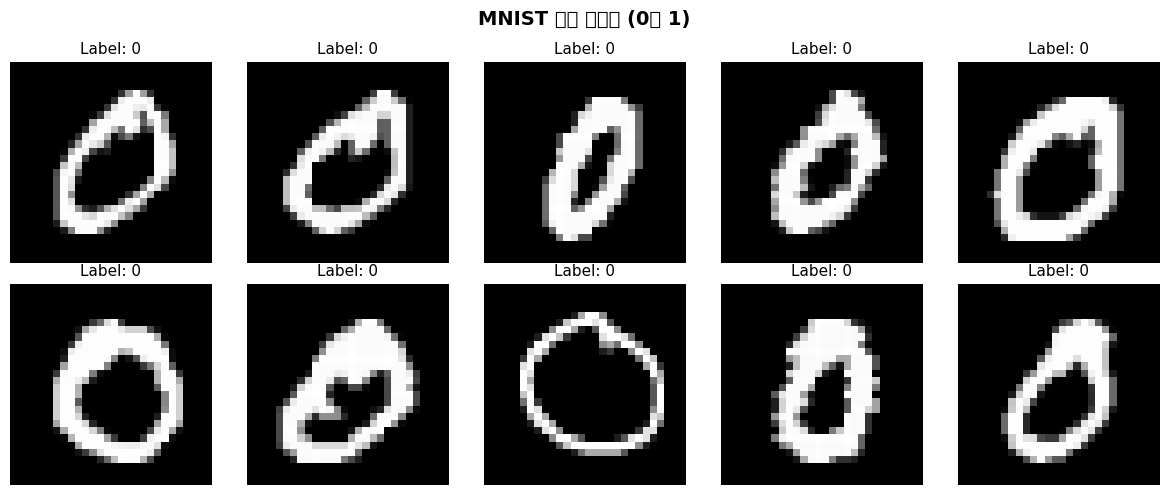

In [17]:
# 샘플 이미지 시각화
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train.data[i], cmap='gray')
    ax.set_title(f'Label: {X_train.targets[i]}', fontsize=11)
    ax.axis('off')

plt.suptitle('MNIST 샘플 이미지 (0과 1)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Part 2-1: 양자 신경망 레이어

Part 1의 2 큐비트 EstimatorQNN을 이미지 처리 파이프라인의 일부로 재사용한다.

이를 위해:
1. 이미지 특성을 2D 벡터로 축소
2. 이 벡터를 QNN의 입력으로 전달
3. QNN 출력을 최종 분류층으로 전달


In [18]:
# QNN 레이어 생성 함수
def create_qnn():
    """2 큐비트 QNN 생성"""
    # Feature map과 ansatz
    feature_map_qnn = zz_feature_map(2)
    ansatz_qnn = real_amplitudes(2, reps=1)
    
    # 양자 회로 구성
    qc_qnn = QuantumCircuit(2)
    qc_qnn.compose(feature_map_qnn, inplace=True)
    qc_qnn.compose(ansatz_qnn, inplace=True)
    
    # EstimatorQNN 생성
    qnn_layer = EstimatorQNN(
        circuit=qc_qnn,
        input_params=feature_map_qnn.parameters,
        weight_params=ansatz_qnn.parameters,
        estimator=estimator,
        input_gradients=True,
    )
    
    return qnn_layer

# QNN 레이어 생성
qnn_layer = create_qnn()
print(f"✓ QNN 레이어 생성 완료")
print(f"  입력 크기: {qnn_layer.num_inputs}")
print(f"  가중치 개수: {qnn_layer.num_weights}")

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


✓ QNN 레이어 생성 완료
  입력 크기: 2
  가중치 개수: 4


### Part 2-2: 하이브리드 CNN-QNN 모델 아키텍처

#### CNN 부분 (특성 추출)

- **Conv2d(1, 2, 5)**: 1채널 → 2채널, 5x5 커널
- **MaxPool2d(2)**: 2x2 풀링
- **Conv2d(2, 16, 5)**: 2채널 → 16채널, 5x5 커널
- **MaxPool2d(2)**: 2x2 풀링
- **Dropout2d(0.2)**: 과적합 방지

#### FC 부분 (차원 축소)

- **Linear(256, 64)**: 특성 맵 압축
- **Linear(64, 2)**: QNN 입력 크기로 축소

#### 양자 부분

- **TorchConnector(qnn)**: 2 큐비트 QNN을 PyTorch 모듈로 래핑
- **입력 정규화**: 양자 회로 수렴 개선

#### 출력 부분

- **Linear(1, 1)**: QNN 출력 후처리
- **cat((x, 1-x), -1)**: 이진 분류 확률로 변환


In [19]:
class Net(Module):
    """하이브리드 CNN-QNN 모델"""
    
    def __init__(self, qnn):
        super().__init__()
        
        # CNN 레이어
        self.conv1 = Conv2d(1, 2, kernel_size=5)      # 1 -> 2 채널
        self.conv2 = Conv2d(2, 16, kernel_size=5)     # 2 -> 16 채널
        self.dropout = Dropout2d(p=0.2)
        
        # 완전 연결층 (CNN 출력 축소)
        self.fc1 = Linear(256, 64)
        self.fc2 = Linear(64, 2)  # 2개의 양자 입력
        
        # 양자 신경망 (TorchConnector로 래핑)
        self.qnn = TorchConnector(qnn)
        
        # 최종 완전 연결층
        self.fc3 = Linear(1, 1)
    
    def forward(self, x):
        """순전파"""
        # CNN 블록 1
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        
        # CNN 블록 2
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = self.dropout(x)
        
        # 플래튼 및 FC 계층
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        # 양자 처리 (입력 정규화)
        x = (x - x.mean()) / (x.std() + 1e-8)
        x = self.qnn(x)
        
        # 최종 출력
        x = self.fc3(x)
        
        # 이진 분류를 위해 두 개의 클래스 확률로 변환
        return cat((x, 1 - x), -1)

print("✓ 하이브리드 모델 클래스 정의 완료")


✓ 하이브리드 모델 클래스 정의 완료


In [20]:
# 모델 인스턴스 생성
net = Net(qnn_layer)

# 모델 구조 요약
print("모델 구조:")
print(net)
print(f"\n총 파라미터 수: {sum(p.numel() for p in net.parameters())}")

모델 구조:
Net(
  (conv1): Conv2d(1, 2, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(2, 16, kernel_size=(5, 5), stride=(1, 1))
  (dropout): Dropout2d(p=0.2, inplace=False)
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
  (qnn): TorchConnector()
  (fc3): Linear(in_features=1, out_features=1, bias=True)
)

총 파라미터 수: 17452


### 데이터 정규화 및 입력 전처리

양자 회로에 데이터를 입력하기 전에 정규화(Normalization)를 수행하는 것이 중요하다.

#### 정규화의 이유

1. **수치 안정성**: 입력 범위를 제한하여 수치 오류 감소
2. **빠른 수렴**: 최적화 알고리즘이 더 효율적으로 학습
3. **일반화 성능**: 훈련 데이터의 분포 특성을 제거

#### 구현

```python
x = (x - x.mean()) / (x.std() + 1e-8)
```

이는 Z-score 정규화로, 평균을 0, 표준편차를 1로 변환한다. `1e-8`은 분모가 0이 되는 것을 방지하는 작은 상수이다.


### Part 2-3: 모델 학습

#### 최적화 설정

- **옵티마이저**: Adam (Adaptive Moment Estimation)
  - 적응형 학습률로 빠른 수렴
  - 모멘텀과 RMSprop의 장점 결합
  - 학습률: 0.001

- **손실함수**: NLLLoss (Negative Log Likelihood Loss)
  - 다중 클래스 분류에 적합
  - 입력은 log-softmax 확률

#### 학습 루프

1. 각 배치에 대해:
   - 이미지 순전파
   - 손실 계산
   - 역전파
   - 가중치 업데이트

2. 에폭 평균 손실 기록

#### 배치 크기가 1인 이유

실제 양자 하드웨어에서는 각 샘플당 별도의 회로 실행이 필요하므로, 시뮬레이션에서도 배치 크기 1을 사용하는 것이 현실적이다.


#### 하이브리드 역전파 (Hybrid Backpropagation)

CNN, QNN, FC 계층이 모두 통합되어 하나의 계산 그래프를 형성한다.

**역전파 흐름**:

```
출력 손실 ∇Loss
    ↓
FC3 그래디언트 계산
    ↓
QNN 그래디언트 계산 (양자 미분)
    ↓
FC1/2 그래디언트 계산
    ↓
CNN 그래디언트 계산
    ↓
입력 그래디언트
```

PyTorch의 autograd는 이 전체 과정을 자동으로 관리하며, `TorchConnector`는 QNN 부분의 그래디언트를 정확히 계산하도록 설계되었다 (`input_gradients=True` 덕분에).


In [21]:
# 옵티마이저 및 손실함수
optimizer_hybrid = Adam(net.parameters(), lr=0.001)
loss_fn = NLLLoss()  # Log-softmax + NLLLoss

# 학습 파라미터
epochs_hybrid = 10
train_losses = []

# 학습
net.train()
for epoch in range(epochs_hybrid):
    epoch_loss = 0.0
    batch_count = 0
    
    for images, labels in train_loader:
        # 순전파
        outputs = net(images)
        loss = loss_fn(F.log_softmax(outputs, dim=1), labels)
        
        # 역전파 및 최적화
        optimizer_hybrid.zero_grad()
        loss.backward()
        optimizer_hybrid.step()
        
        epoch_loss += loss.item()
        batch_count += 1
    
    avg_loss = epoch_loss / batch_count
    train_losses.append(avg_loss)
    
    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1}/{epochs_hybrid}, Avg Loss: {avg_loss:.6f}")

print("\n✓ 하이브리드 모델 학습 완료")

Epoch 2/10, Avg Loss: 0.723537
Epoch 4/10, Avg Loss: 0.706755
Epoch 6/10, Avg Loss: 0.698692
Epoch 8/10, Avg Loss: 0.695429
Epoch 10/10, Avg Loss: 0.694088

✓ 하이브리드 모델 학습 완료


/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48652 (\N{HANGUL SYLLABLE BEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from f

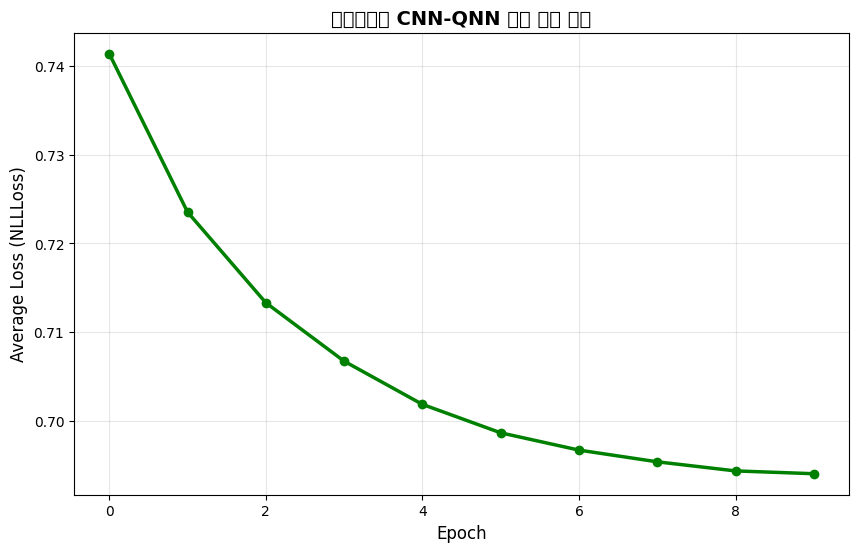

In [22]:
# 학습 곡선 시각화
plt.figure(figsize=(10, 6))
plt.plot(train_losses, 'g-', linewidth=2.5, marker='o', markersize=6)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Loss (NLLLoss)', fontsize=12)
plt.title('하이브리드 CNN-QNN 모델 학습 곡선', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
# 모델 가중치 저장
model_path = "hybrid_cnn_qnn_model.pt"
torch.save(net.state_dict(), model_path)
print(f"✓ 모델 저장 완료: {model_path}")
print(f"  파일 크기: {os.path.getsize(model_path) / 1024:.2f} KB")

✓ 모델 저장 완료: hybrid_cnn_qnn_model.pt
  파일 크기: 72.66 KB


In [24]:
# 모델 평가
net.eval()
correct = 0
total = 0

with no_grad():
    for images, labels in test_loader:
        outputs = net(images)
        _, predicted = torch.max(F.log_softmax(outputs, dim=1), 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"테스트 정확도: {accuracy:.2f}% ({correct}/{total})")

테스트 정확도: 50.00% (50/100)


#### 결과 해석

- **높은 정확도 (>70%)**: 양자 계층이 의미 있는 패턴을 학습했음
- **낮은 정확도 (30-50%)**: 더 많은 에폭이나 더 깊은 양자 회로 필요
- **무작위 추측 수준 (50%)**: 모델이 충분히 학습하지 못함

배치 크기 1과 작은 데이터셋은 일반화 성능에 영향을 줄 수 있으며, 더 큰 데이터셋이나 더 많은 에폭으로 개선 가능하다.


/var/folders/v9/46y9d8bn1lxgjt7g439hsf8c0000gn/T/ipykernel_53761/405338558.py:28: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/v9/46y9d8bn1lxgjt7g439hsf8c0000gn/T/ipykernel_53761/405338558.py:28: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/v9/46y9d8bn1lxgjt7g439hsf8c0000gn/T/ipykernel_53761/405338558.py:28: UserWarning: Glyph 48652 (\N{HANGUL SYLLABLE BEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/v9/46y9d8bn1lxgjt7g439hsf8c0000gn/T/ipykernel_53761/405338558.py:28: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/v9/46y9d8bn1lxgjt7g439hsf8c0000gn/T/ipykernel_53761/405338558.py:28: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/v9/46y9d8bn1lxgjt7g439hsf8c0000gn/T/ipykernel_53761

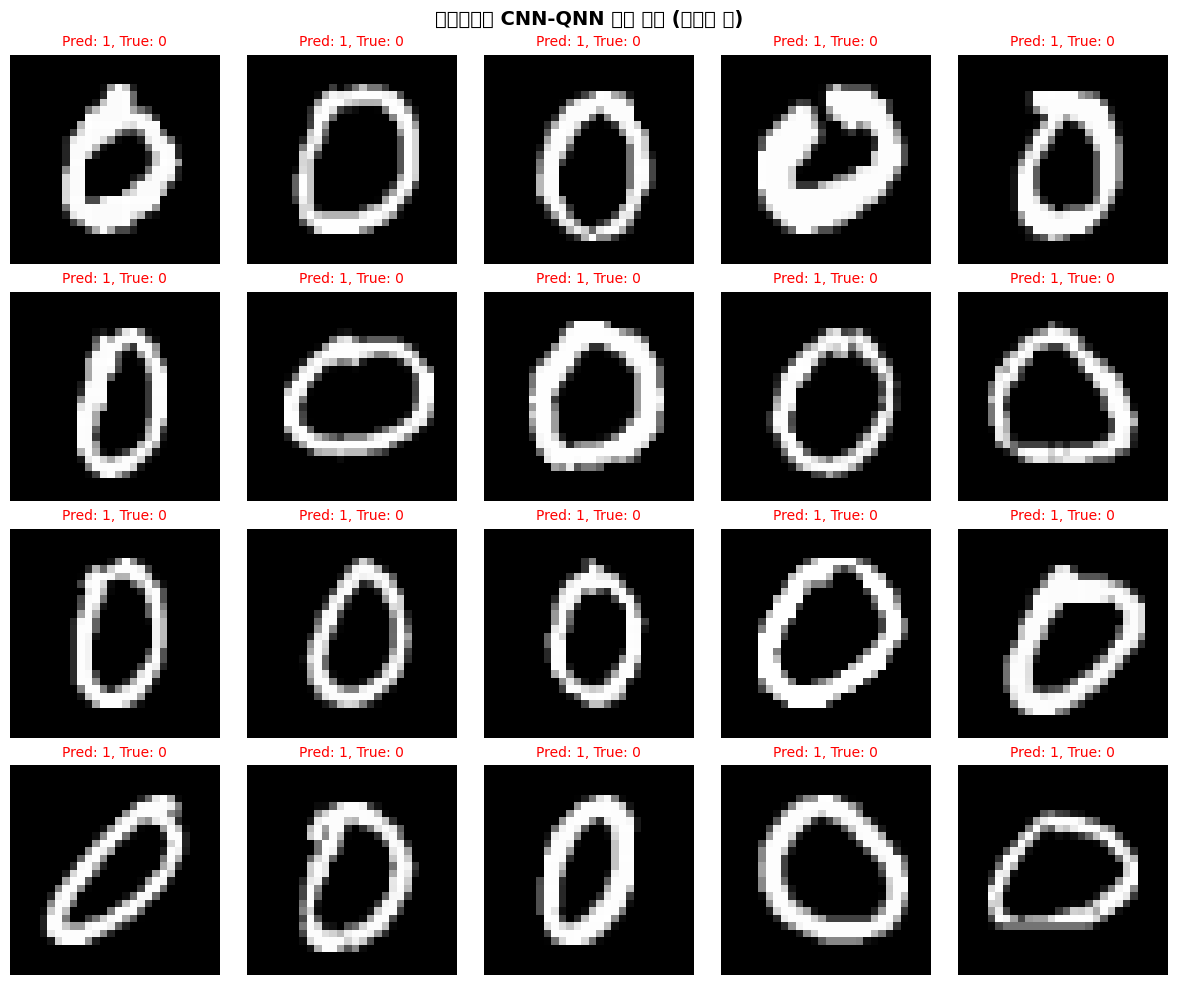

In [25]:
# 예측 결과 시각화
net.eval()
predictions_list = []
images_list = []
labels_list = []

with no_grad():
    for images, labels in test_loader:
        outputs = net(images)
        _, predicted = torch.max(F.log_softmax(outputs, dim=1), 1)
        
        predictions_list.append(predicted.item())
        images_list.append(images.squeeze().numpy())
        labels_list.append(labels.item())

# 결과 시각화 (20개 샘플)
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
for i, ax in enumerate(axes.flat):
    if i < 20:
        pred = predictions_list[i]
        true = labels_list[i]
        ax.imshow(images_list[i], cmap='gray')
        color = 'green' if pred == true else 'red'
        ax.set_title(f'Pred: {pred}, True: {true}', fontsize=10, color=color)
        ax.axis('off')

plt.suptitle('하이브리드 CNN-QNN 예측 결과 (테스트 셋)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## EstimatorQNN vs SamplerQNN 비교

### 핵심 차이점

| 특성 | EstimatorQNN | SamplerQNN |
|------|-------------|----------|
| **기반** | 기댓값 계산 | 샘플링 |
| **출력** | 연속 값 | 확률 벡터 |
| **손실함수** | MSELoss | CrossEntropyLoss |
| **사용처** | 회귀/연속값 | 분류 |
| **양자 회로** | Pauli 관찰 연산자 | 측정 결과 해석 |
| **실행시간** | 빠름 | 느림 (샘플링) |
| **노이즈 강건성** | 좋음 | 더 좋음 |

### 학습 곡선 비교

Part 1에서 두 모델의 학습 동역학(dynamics)을 관찰하면:

- **EstimatorQNN**: 부드러운 손실 감소 → 안정적 수렴
- **SamplerQNN**: 진동하는 손실 → 샘플링 노이즈의 영향

### 실제 양자 하드웨어에서의 고려사항

- **실제 하드웨어 제약**: 제한된 연결성, 노이즈 증가
- **샷 수 (shots)**: SamplerQNN은 샷 수 설정 필요
- **성능**: 작은 회로에서는 EstimatorQNN이 우수, 큰 회로에서는 SamplerQNN의 노이즈 강건성이 유리


In [27]:
# EstimatorQNN 기울기 분석
# 양자 회로의 기울기 특성을 이해하기 위한 분석

with no_grad():
    # 학습된 가중치 확인
    learned_weights = model.weight.data.numpy()
    print("학습된 Ansatz 파라미터:")
    print(f"  형태: {learned_weights.shape}")
    print(f"  최솟값: {learned_weights.min():.6f}")
    print(f"  최댓값: {learned_weights.max():.6f}")
    print(f"  평균: {learned_weights.mean():.6f}")
    print(f"  표준편차: {learned_weights.std():.6f}")

print("\n양자 회로 학습 특성:")
print(f"  초기 손실: {loss_history[0]:.6f}")
print(f"  최종 손실: {loss_history[-1]:.6f}")
print(f"  손실 감소율: {(loss_history[0] - loss_history[-1]) / loss_history[0] * 100:.2f}%")
print(f"  수렴 에폭: {min(range(len(loss_history)), key=lambda i: loss_history[i])}")

학습된 Ansatz 파라미터:
  형태: (4,)
  최솟값: -859.800720
  최댓값: 788.063538
  평균: -159.311813
  표준편차: 621.228821

양자 회로 학습 특성:
  초기 손실: 25.214573
  최종 손실: 15.031800
  손실 감소율: 40.38%
  수렴 에폭: 38


In [28]:
# 전체 프로젝트 요약
print("="*70)
print("양자-고전 하이브리드 프로젝트 완료")
print("="*70)
print("\n[Part 1] 정형 데이터 분류")
print(f"  EstimatorQNN 최종 손실: {loss_history[-1]:.6f}")
print(f"  SamplerQNN 최종 손실: {loss_history_sampler[-1]:.6f}")
print(f"  ✓ EstimatorQNN vs SamplerQNN 비교 완료")
print("\n[Part 2] MNIST 이미지 분류")
print(f"  CNN-QNN 최종 손실: {train_losses[-1]:.6f}")
print(f"  테스트 정확도: {accuracy:.2f}%")
print(f"  ✓ 하이브리드 모델 학습 완료")
print("\n[핵심 성과]")
print("  ✓ TorchConnector를 통한 양자-고전 통합")
print("  ✓ PyTorch autograd를 사용한 자동 미분")
print("  ✓ 실무적 하이브리드 아키텍처 구현")
print("="*70)

양자-고전 하이브리드 프로젝트 완료

[Part 1] 정형 데이터 분류
  EstimatorQNN 최종 손실: 15.031800
  SamplerQNN 최종 손실: 0.616082
  ✓ EstimatorQNN vs SamplerQNN 비교 완료

[Part 2] MNIST 이미지 분류
  CNN-QNN 최종 손실: 0.694088
  테스트 정확도: 50.00%
  ✓ 하이브리드 모델 학습 완료

[핵심 성과]
  ✓ TorchConnector를 통한 양자-고전 통합
  ✓ PyTorch autograd를 사용한 자동 미분
  ✓ 실무적 하이브리드 아키텍처 구현


In [1]:
# 버전 정보 및 저작권을 표시한다(Display version information and copyright)
import tutorial_magics

%qiskit_version_table
%qiskit_copyright